# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV141"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv141')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv141/lv141-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV141,gene_band
0,HNRNPC,7.597513,14q11.2
1,PTCH1,6.794863,9q22.32
2,GAN,6.362439,16q23.2
3,NOP56,5.090175,20p13
4,UBE2L3,4.795480,22q11.21
5,CANT1,4.784765,17q25.3
6,MARCKSL1,3.893966,1p35.1
7,IMPA2,3.869267,18p11.21
8,SGMS1,3.799112,10q11.23
9,SYNJ1,3.732801,21q22.11


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 15:34:38,206 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 15:34:38,206 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP057205, SRP055569, SRP042161, SRP011054, SRP033135, SRP064464, SRP047192, SRP057196, SRP060416, SRP012461, SRP034698, SRP040236, SRP058773, SRP018104, SRP050499, SRP066834, SRP045659, SRP006474, SRP015013, SRP033248, SRP032798, SRP009266, SRP019241, SRP008775, SRP001758, SRP041788, SRP055153, SRP034586, SRP059379, SRP043085, SRP049475, SRP059775, SRP011185, SRP040772, SRP009862, SRP024268, SRP050992, SRP047516, SRP000599, SRP017411, SRP007947, SRP034666, SRP055810, SRP056604, SRP005279, SRP014670, SRP002543, SRP031459, SRP040525, SRP027383, SRP014142, SRP048761, SRP016003, SRP040442, SRP059039, SRP022892, SRP007338, SRP063867, SRP049340, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (57 != 59)
  warnings.warn(


In [12]:
lv_data.shape

(6817, 97)

In [13]:
lv_data.head()

cell line gfp cd13 ssea4 tra160 cell type patient id  \
project   run                                                                  
SRP057205 SRR1975508  Detroit 551  NA   NA    NA     NA       NaN        NaN   
          SRR1975507  Detroit 551  NA   NA    NA     NA       NaN        NaN   
          SRR1975506  Detroit 551  NA   NA    NA     NA       NaN        NaN   
          SRR1975505  Detroit 551  NA   NA    NA     NA       NaN        NaN   
          SRR1975503  Detroit 551   -   NA     +      +       NaN        NaN   

                     subtype antibody passages  ... severity flowcell lane  \
project   run                                   ...                          
SRP057205 SRR1975508     NaN      NaN      NaN  ...      NaN      NaN  NaN   
          SRR1975507     NaN      NaN      NaN  ...      NaN      NaN  NaN   
          SRR1975506     NaN      NaN      NaN  ...      NaN      NaN  NaN   
          SRR1975505     NaN      NaN      NaN  ...      NaN      NaN  NaN   
          SRR1975503     NaN      NaN      NaN  ...      NaN      NaN  NaN   

                     culture medium library type read length data set  \
project   run                                                           
SRP057205 SRR1975508            NaN          NaN         NaN      NaN   
          SRR1975507            NaN          NaN         NaN      NaN   
          SRR1975506            NaN          NaN         NaN      NaN   
          SRR1975505            NaN          NaN         NaN      NaN   
          SRR1975503            NaN          NaN         NaN      NaN   

                     passage (pre-reprogramming) surface antigen enrichment  \
project   run                                                                 
SRP057205 SRR1975508                         NaN                        NaN   
          SRR1975507                         NaN                        NaN   
          SRR1975506                         NaN                        NaN   
          SRR1975505                         NaN                        NaN   
          SRR1975503                         NaN                        NaN   

                         LV141  
project   run                   
SRP057205 SRR1975508 -0.010864  
          SRR1975507 -0.015505  
          SRR1975506 -0.010003  
          SRR1975505 -0.008555  
          SRR1975503  0.150780  

[5 rows x 97 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

gfp                                       3.161130
cd13                                      3.161130
ssea4                                     3.161130
tra160                                    3.161130
cell line                                 0.274415
antibody                                  0.013256
antibody vendor                           0.008064
lot number                                0.007469
3' adaptor                                0.007338
infection                                 0.006644
shRNA treatment                           0.006644
dilutions of the malignant b-cell line    0.005205
growth protocol                           0.004751
time                                      0.002898
c1 chip id                                0.002671
experiment_sample_name                    0.002671
survival                                  0.002391
disease state                             0.002349
library source                            0.002201
iPSc                           

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

cell line      0.274415
tissue         0.001802
cell type      0.001712
tissue type    0.000453
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "cell line",
    "tissue",
    "cell type",
    "tissue type",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

cell line    tissue  \
project   run                                 
SRP057205 SRR1975499  Detroit 551       NaN   
          SRR1975500  Detroit 551       NaN   
SRP055569 SRR2019007          NaN       NaN   
          SRR1821483          NaN       NaN   
SRP042161 SRR1295238         CSC6       NaN   
SRP011054 SRR452334           NaN       NaN   
SRP033135 SRR1033017          NaN       NaN   
SRP064464 SRR2558180          NaN       NaN   
SRP055569 SRR1821394          NaN       NaN   
          SRR1821476          NaN       NaN   
SRP057205 SRR1975492  Detroit 551       NaN   
          SRR1975491  Detroit 551       NaN   
SRP047192 SRR1576168         Mcf7       NaN   
SRP055569 SRR2019045          NaN       NaN   
          SRR2019070          NaN       NaN   
SRP057196 SRR1974544          NaN    cortex   
SRP060416 SRR2088186          NaN       NaN   
SRP055569 SRR2019087          NaN       NaN   
          SRR1821364          NaN       NaN   
SRP057196 SRR1975002          NaN    cortex   
SRP055569 SRR1821486          NaN       NaN   
SRP057196 SRR1974843          NaN    cortex   
SRP012461 SRR490414           NaN       NaN   
SRP034698 SRR1057527          NaN  Melanoma   
SRP040236 SRR1197162     SKOV3ip1       NaN   

                                                              cell type  \
project   run                                                             
SRP057205 SRR1975499                                                NaN   
          SRR1975500                                                NaN   
SRP055569 SRR2019007                             U87 human glioma cells   
          SRR1821483  mixture of U87 human glioma cells and MCF10a h...   
SRP042161 SRR1295238                             Gliomasphere Cell Line   
SRP011054 SRR452334                                              HCT116   
SRP033135 SRR1033017             Human Skeletal Muscle Myoblasts (HSMM)   
SRP064464 SRR2558180                                                NaN   
SRP055569 SRR1821394                             U87 human glioma cells   
          SRR1821476  mixture of U87 human glioma cells and MCF10a h...   
SRP057205 SRR1975492                                                NaN   
          SRR1975491                                                NaN   
SRP047192 SRR1576168                                                NaN   
SRP055569 SRR2019045                             U87 human glioma cells   
          SRR2019070                  WI-38 human lung fibroblast cells   
SRP057196 SRR1974544                                             hybrid   
SRP060416 SRR2088186                       tonsil Innate lymphoid cells   
SRP055569 SRR2019087                  WI-38 human lung fibroblast cells   
          SRR1821364                             U87 human glioma cells   
SRP057196 SRR1975002                                    fetal_quiescent   
SRP055569 SRR1821486  mixture of U87 human glioma cells and MCF10a h...   
SRP057196 SRR1974843                                            neurons   
SRP012461 SRR490414                                         Fibroblasts   
SRP034698 SRR1057527                                                NaN   
SRP040236 SRR1197162                             ovarian adenocarcinoma   

                     tissue type     LV141  
project   run                               
SRP057205 SRR1975499         NaN  9.577487  
          SRR1975500         NaN  9.572314  
SRP055569 SRR2019007         NaN  0.871590  
          SRR1821483         NaN  0.544365  
SRP042161 SRR1295238         NaN  0.493772  
SRP011054 SRR452334          NaN  0.432964  
SRP033135 SRR1033017         NaN  0.342616  
SRP064464 SRR2558180         NaN  0.320234  
SRP055569 SRR1821394         NaN  0.304548  
          SRR1821476         NaN  0.301244  
SRP057205 SRR1975492         NaN  0.289487  
          SRR1975491         NaN  0.287985  
SRP047192 SRR1576168         NaN  0.281539  
SRP055569 SRR2019045         NaN  0.264020  
        

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

cell line           tissue  \
project   run                                        
SRP057196 SRR1974892          NaN           cortex   
SRP057205 SRR1975465           H9              NaN   
          SRR1975466           H9              NaN   
SRP057196 SRR1974879          NaN           cortex   
SRP058773 SRR2042623          NaN              NaN   
SRP055569 SRR2018982          NaN              NaN   
          SRR1821673          NaN              NaN   
          SRR1821557          NaN              NaN   
SRP057205 SRR1975486  Detroit 551              NaN   
SRP018104 SRR651723        HEK293              NaN   
SRP057205 SRR1975485  Detroit 551              NaN   
SRP018104 SRR651722        HEK293              NaN   
SRP050499 SRR2013711          NaN              NaN   
SRP055569 SRR1821361          NaN              NaN   
SRP047192 SRR1576167         K562              NaN   
SRP057196 SRR1974637          NaN           cortex   
SRP055569 SRR1821587          NaN              NaN   
          SRR2019163          NaN              NaN   
SRP060416 SRR2088140          NaN              NaN   
SRP057196 SRR1974606          NaN           cortex   
SRP060416 SRR2088256          NaN              NaN   
SRP018104 SRR651725        HEK293              NaN   
SRP057196 SRR1974762          NaN           cortex   
SRP057205 SRR1975477  Detroit 551              NaN   
SRP066834 SRR2967677          NaN  Fetal neocortex   

                                                              cell type  \
project   run                                                             
SRP057196 SRR1974892                                  fetal_replicating   
SRP057205 SRR1975465                                                NaN   
          SRR1975466                                                NaN   
SRP057196 SRR1974879                                  fetal_replicating   
SRP058773 SRR2042623                                                NaN   
SRP055569 SRR2018982  mixture of U87 human glioma cells and MCF10a h...   
          SRR1821673                   MCF10a human breast cancer cells   
          SRR1821557  mixture of U87 human glioma cells and MCF10a h...   
SRP057205 SRR1975486                                                NaN   
SRP018104 SRR651723                                                 NaN   
SRP057205 SRR1975485                                                NaN   
SRP018104 SRR651722                                                 NaN   
SRP050499 SRR2013711                                                NaN   
SRP055569 SRR1821361                             U87 human glioma cells   
SRP047192 SRR1576167                                                NaN   
SRP057196 SRR1974637                                         astrocytes   
SRP055569 SRR1821587  mixture of U87 human glioma cells and MCF10a h...   
          SRR2019163  mixture of U87 human glioma cells and WI-38 hu...   
SRP060416 SRR2088140                       tonsil Innate lymphoid cells   
SRP057196 SRR1974606                                          microglia   
SRP060416 SRR2088256                       tonsil Innate lymphoid cells   
SRP018104 SRR651725                                                 NaN   
SRP057196 SRR1974762                                            neurons   
SRP057205 SRR1975477                                                NaN   
SRP066834 SRR2967677                                                NaN   

                     tissue type     LV141  
project   run                               
SRP057196 SRR1974892         NaN  0.198254  
SRP057205 SRR1975465         NaN  0.188417  
          SRR1975466         NaN  0.187708  
SRP057196 SRR1974879         NaN  0.186683  
SRP058773 SRR2042623         NaN  0.184668  
SRP055569 SRR2018982         NaN  0.179807  
          SRR1821673         NaN  0.177771  
          SRR1821557         NaN  0.175497  
SRP057205 SRR1975486         NaN  0.175337  
SRP018104 SRR651723          NaN  0.174401  

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [21]:
# list the top 10 samples from this project
lv_data.loc[["SRP039591"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP039591'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [22]:
SELECTED_ATTRIBUTES = [
    "cell line",
    "tissue",
    "cell type",
    "tissue type",
]

## Get a single attribute with "cell type/tissue" information

In [23]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [24]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [25]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [26]:
plot_data.head(20)

cell line  \
project   run                                                             
SRP057205 SRR1975499                                        Detroit 551   
          SRR1975500                                        Detroit 551   
SRP055569 SRR2019007                             U87 human glioma cells   
          SRR1821483  mixture of U87 human glioma cells and MCF10a h...   
SRP042161 SRR1295238                                               CSC6   
SRP011054 SRR452334                                              HCT116   
SRP033135 SRR1033017             Human Skeletal Muscle Myoblasts (HSMM)   
SRP064464 SRR2558180                                    NOT CATEGORIZED   
SRP055569 SRR1821394                             U87 human glioma cells   
          SRR1821476  mixture of U87 human glioma cells and MCF10a h...   
SRP057205 SRR1975492                                        Detroit 551   
          SRR1975491                                        Detroit 551   
SRP047192 SRR1576168                                               Mcf7   
SRP055569 SRR2019045                             U87 human glioma cells   
          SRR2019070                  WI-38 human lung fibroblast cells   
SRP057196 SRR1974544                                             cortex   
SRP060416 SRR2088186                       tonsil Innate lymphoid cells   
SRP055569 SRR2019087                  WI-38 human lung fibroblast cells   
          SRR1821364                             U87 human glioma cells   
SRP057196 SRR1975002                                             cortex   

                         LV141  
project   run                   
SRP057205 SRR1975499  9.577487  
          SRR1975500  9.572314  
SRP055569 SRR2019007  0.871590  
          SRR1821483  0.544365  
SRP042161 SRR1295238  0.493772  
SRP011054 SRR452334   0.432964  
SRP033135 SRR1033017  0.342616  
SRP064464 SRR2558180  0.320234  
SRP055569 SRR1821394  0.304548  
          SRR1821476  0.301244  
SRP057205 SRR1975492  0.289487  
          SRR1975491  0.287985  
SRP047192 SRR1576168  0.281539  
SRP055569 SRR2019045  0.264020  
          SRR2019070  0.261591  
SRP057196 SRR1974544  0.251450  
SRP060416 SRR2088186  0.240791  
SRP055569 SRR2019087  0.237320  
          SRR1821364  0.226365  
SRP057196 SRR1975002  0.224293

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [27]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [28]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [29]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [30]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [31]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [32]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [33]:
N_TOP_ATTRS = 10

In [34]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [35]:
len(attr_order)

10

In [36]:
attr_order[:5]

['Detroit 551',
 'U87 human glioma cells',
 'mixture of U87 human glioma cells and MCF10a human breast cancer cells',
 'CSC6',
 'HCT116']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

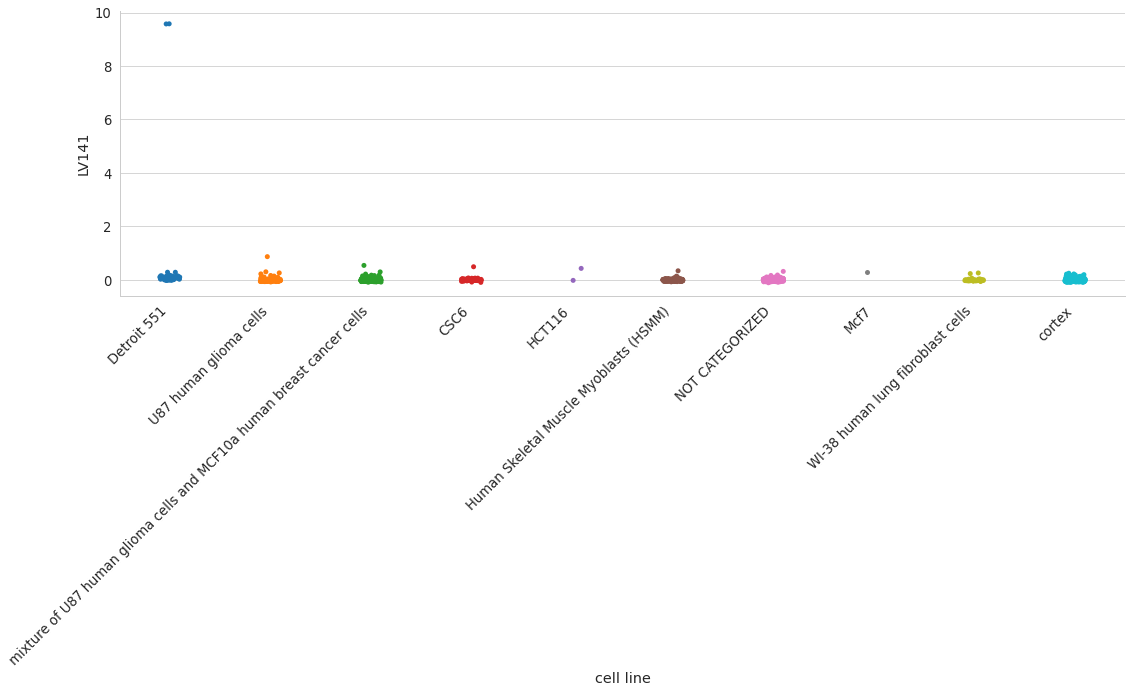

In [37]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [38]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("Detroit")
    ]
    display(_tmp.head(20))

cell line     LV141
project   run                              
SRP057205 SRR1975499  Detroit 551  9.577487
          SRR1975500  Detroit 551  9.572314
          SRR1975492  Detroit 551  0.289487
          SRR1975491  Detroit 551  0.287985
          SRR1975486  Detroit 551  0.175337
          SRR1975485  Detroit 551  0.169627
          SRR1975477  Detroit 551  0.154895
          SRR1975478  Detroit 551  0.154230
          SRR1975503  Detroit 551  0.150780
          SRR1975504  Detroit 551  0.150079
          SRR1975493  Detroit 551  0.148080
          SRR1975494  Detroit 551  0.147454
          SRR1975487  Detroit 551  0.146173
          SRR1975473  Detroit 551  0.109797
          SRR1975474  Detroit 551  0.109508
          SRR1975459  Detroit 551  0.109031
          SRR1975460  Detroit 551  0.108740
          SRR1975497  Detroit 551  0.107607
          SRR1975455  Detroit 551  0.107491
          SRR1975482  Detroit 551  0.107362

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP057205, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP057205"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell line gfp cd13 ssea4 tra160     LV141
project   run                                                    
SRP057205 SRR1975499  Detroit 551   -   NA     +      -  9.577487
          SRR1975500  Detroit 551   -   NA     +      -  9.572314
          SRR1975492  Detroit 551   -   NA     +      +  0.289487
          SRR1975491  Detroit 551   -   NA     +      +  0.287985
          SRR1975465           H9  NA   NA    NA     NA  0.188417
          SRR1975466           H9  NA   NA    NA     NA  0.187708
          SRR1975486  Detroit 551   +   NA     -      -  0.175337
          SRR1975485  Detroit 551   +   NA     -      -  0.169627
          SRR1975477  Detroit 551   +    +     -     NA  0.154895
          SRR1975478  Detroit 551   +    +     -     NA  0.154230
          SRR1975503  Detroit 551   -   NA     +      +  0.150780
          SRR1975504  Detroit 551   -   NA     +      +  0.150079
          SRR1975493  Detroit 551   -   NA     +      +  0.148080
          SRR1975494  Detroit 551   -   NA     +      +  0.147454
          SRR1975487  Detroit 551   -   NA     +      -  0.146173
          SRR1975463           H1  NA   NA    NA     NA  0.141653
          SRR1975464           H1  NA   NA    NA     NA  0.141360
          SRR1975467         PGP1  NA   NA    NA     NA  0.137427
          SRR1975468         PGP1  NA   NA    NA     NA  0.137162
          SRR1975473  Detroit 551   +    +    NA     NA  0.109797
          SRR1975474  Detroit 551   +    +    NA     NA  0.109508
          SRR1975459  Detroit 551  NA   NA    NA     NA  0.109031
          SRR1975460  Detroit 551  NA   NA    NA     NA  0.108740
          SRR1975497  Detroit 551   +   NA     +      -  0.107607
          SRR1975455  Detroit 551  NA   NA    NA     NA  0.107491
          SRR1975482  Detroit 551   +    -     +     NA  0.107362
          SRR1975498  Detroit 551   +   NA     +      -  0.107218
          SRR1975456  Detroit 551  NA   NA    NA     NA  0.107138
          SRR1975481  Detroit 551   +    -     +     NA  0.106675
          SRR1975457  Detroit 551  NA   NA    NA     NA  0.096320
          SRR1975458  Detroit 551  NA   NA    NA     NA  0.096054
          SRR1975488  Detroit 551   -   NA     +      -  0.077017
          SRR1975469  Detroit 551   +    -    NA     NA  0.063911
          SRR1975470  Detroit 551   +    -    NA     NA  0.063908
          SRR1975475  Detroit 551   +    -     -     NA  0.053077
          SRR1975479  Detroit 551   +    +     +     NA  0.053047
          SRR1975480  Detroit 551   +    +     +     NA  0.052734
          SRR1975476  Detroit 551   +    -     -     NA  0.052328
          SRR1975462  Detroit 551  NA   NA    NA     NA  0.027939
          SRR1975501  Detroit 551   -   NA     +      +  0.027924
          SRR1975461  Detroit 551  NA   NA    NA     NA  0.027917
          SRR1975502  Detroit 551   -   NA     +      +  0.027490
          SRR1975489  Detroit 551   +   NA     +      -  0.013985
          SRR1975490  Detroit 551   +   NA     +      -  0.013498
          SRR1975484  Detroit 551   -    -     +     NA  0.013459
          SRR1975483  Detroit 551   -    -     +     NA  0.013109
          SRR1975453  Detroit 551  NA   NA    NA     NA  0.011542
          SRR1975454  Detroit 551  NA   NA    NA     NA  0.011450
          SRR1975472  Detroit 551   +    +    NA     NA  0.001346
          SRR1975471  Detroit 551   +    +    NA     NA  0.001268
          SRR1975495  Detroit 551   +   NA     -      - -0.000362
          SRR1975496  Detroit 551   +   NA     -      - -0.000371
          SRR1975505  Detroit 551  NA   NA    NA     NA -0.008555
          SRR1975506  Detroit 551  NA   NA    NA     NA -0.010003
          SRR1975508  Detroit 551  NA   NA    NA     NA -0.010864
          SRR1975507  Detroit 551  NA   NA    NA     NA -0.015505

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.